# Library Import

In [1]:
import cv2
import matplotlib.pyplot as plt
import warnings

from keras import Sequential
from keras.src.callbacks import CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard, ModelCheckpoint
from keras.src.layers import BatchNormalization, Dense, MaxPooling2D, Dropout, Flatten, Conv2D, Activation
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.optimizers import Adam
from keras.src.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import os
from tqdm import tqdm
from sklearn.utils import shuffle
import plotly.express as px
import plotly.graph_objects as go
import itertools
from keras.src.regularizers import L2

warnings.filterwarnings('ignore')

# PATH

In [2]:
train_path = 'dataset/training/'
PLOT_SAVE_DIR = 'output/plot/v8/'
LOG_DIR = 'output/log/v8/'
MODEL_SAVE_PATH = 'output/model/v8/cnn_model_v8.keras'
HISTORY_PATH = 'output/model/v8/train_history_v8.npy'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 500
LEARNING_RATE = 0.001

LABEL_MAPPING = {
    'alcohol': 0,
    'blood': 1,
    'sexual': 2,
    'traffic_accident': 3
}

class_names = ['alcohol', 'blood', 'sexual', 'traffic_accident']
nb_classes = len(class_names)

# Function to load data

In [3]:
def load_data(dataset, label_mapping, image_size=IMAGE_SIZE):
    images = []
    labels = []

    if isinstance(dataset, str):
        dataset = [dataset]

    for dataset_path in dataset:
        if not os.path.exists(dataset_path):
            raise FileNotFoundError(f"Dataset directory {dataset_path} not found.")

        for folder in os.listdir(dataset_path):
            if folder in label_mapping:
                label = label_mapping[folder]
            else:
                continue

            folder_path = os.path.join(dataset_path, folder)

            if not os.path.isdir(folder_path):
                continue

            for file in tqdm(os.listdir(folder_path)):
                img_path = os.path.join(folder_path, file)

                if not os.path.isfile(img_path):
                    continue

                image = cv2.imread(img_path)

                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                image = cv2.resize(image, image_size)

                image = np.expand_dims(image, axis=-1)

                image = image / 255.0

                images.append(image)
                labels.append(label)

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int')

    return images, labels

# Execute images and labels

In [4]:
images, labels = load_data(train_path, LABEL_MAPPING)

100%|██████████| 500/500 [00:01<00:00, 414.96it/s]


In [5]:
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: (2000, 224, 224, 1)
Labels shape: (2000,)


# Split data into training and testing sets

In [6]:
images, labels = shuffle(images, labels, random_state=10)

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2)
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size=0.5)

In [7]:
train_labels_onehot = to_categorical(train_labels, num_classes=nb_classes)
val_labels_onehot = to_categorical(val_labels, num_classes=nb_classes)
test_labels_onehot = to_categorical(test_labels, num_classes=nb_classes)

In [8]:
print(f"Number of training: {train_labels.shape[0]}")
print(f"Number of validation: {val_labels.shape[0]}")
print(f"Number of testing: {test_labels.shape[0]}")
print(f"Training images are of shape: {train_images.shape}")
print(f"Training labels are of shape: {train_labels_onehot.shape}")
print(f"Validation images are of shape: {val_images.shape}")
print(f"Validation labels are of shape: {val_labels_onehot.shape}")
print(f"Test images are of shape: {test_images.shape}")
print(f"Test labels are of shape: {test_labels_onehot.shape}")

Number of training: 1600
Number of validation: 200
Number of testing: 200
Training images are of shape: (1600, 224, 224, 1)
Training labels are of shape: (1600, 4)
Validation images are of shape: (200, 224, 224, 1)
Validation labels are of shape: (200, 4)
Test images are of shape: (200, 224, 224, 1)
Test labels are of shape: (200, 4)


# Visualize dataset

In [9]:
reverse_label_mapping = {v: k for k, v in LABEL_MAPPING.items()}
class_label_names = [reverse_label_mapping[label] for label in labels]

fig = px.histogram(
    y=class_label_names,
    template='plotly_dark',
    color=class_label_names,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'}
)
fig.show()

In [10]:
_, train_counts = np.unique(train_labels, return_counts=True)
_, val_counts = np.unique(val_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=class_names,
    y=train_counts,
    name='Train',
    marker=dict(color='blue')
))

fig.add_trace(go.Bar(
    x=class_names,
    y=val_counts,
    name='Validation',
    marker=dict(color='green')
))

fig.add_trace(go.Bar(
    x=class_names,
    y=test_counts,
    name='Test',
    marker=dict(color='red')
))

fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark"
)

# Show the plot
fig.show()

In [11]:
fig = go.Figure(data=[go.Pie(
    labels=class_names,
    values=train_counts,
    textinfo='percent+label',
    marker=dict(colors=['blue', 'green', 'red', 'purple']),
)])

fig.update_layout(
    title="Proportion of Each Classes",
    template="plotly_dark",
)

fig.show()

# Data Augmentation

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='wrap',
    brightness_range=(0.8, 1.2),
    channel_shift_range=10,
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)

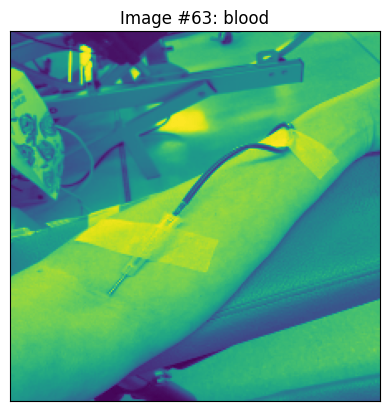

In [13]:
def display_random_image(class_names, images, labels):
    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{}: '.format(index) + class_names[labels[index]])
    plt.show()


display_random_image(class_names, train_images, train_labels)

# Display some dataset

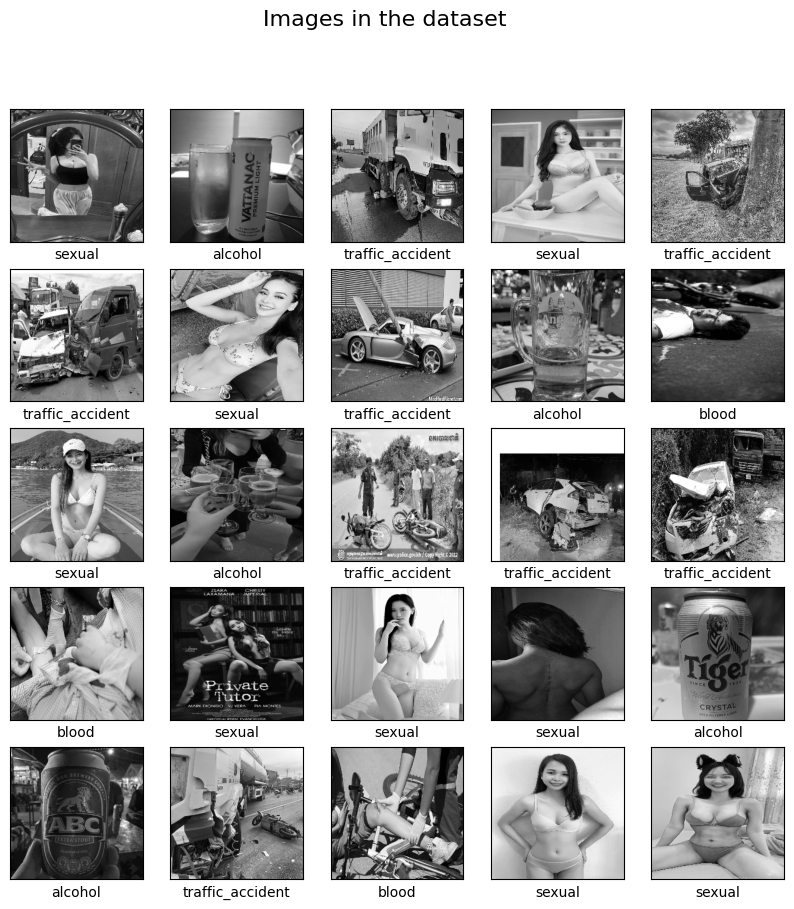

In [14]:
def display_dataset(class_names, images, labels):
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle("Images in the dataset", fontsize=16)

    decoded_labels = np.argmax(labels, axis=1) if len(labels.shape) > 1 else labels

    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.xlabel(class_names[decoded_labels[i]])
    plt.show()


display_dataset(class_names, train_images, train_labels)

# Model architecture

In [15]:
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=L2(0.0001), input_shape=(224, 224, 1)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Flatten
    Flatten(),

    # Fully Connected Layers
    Dense(256, activation='relu', kernel_regularizer=L2(0.0001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(nb_classes, activation='softmax')
])

# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 13,237,124 (50.50 MB)

 Trainable params: 13,235,652 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

# Compile the model

In [16]:
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(patience=20, monitor='val_accuracy', restore_best_weights=True, start_from_epoch=100),
    ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=10, min_lr=1e-6),
    CSVLogger(os.path.join(LOG_DIR, 'training_log_v8.csv'), append=True),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, mode='min'),
    TensorBoard(log_dir=os.path.join(LOG_DIR, "tensorboard_logs"), histogram_freq=1)
]

# Train
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

# Saved model
model.save(MODEL_SAVE_PATH)
np.save(HISTORY_PATH, history.history)

Epoch 1/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.2562 - loss: 1.7697 - val_accuracy: 0.2550 - val_loss: 1.6440 - learning_rate: 0.0010
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.2747 - loss: 1.7165 - val_accuracy: 0.2550 - val_loss: 1.7444 - learning_rate: 0.0010
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.2496 - loss: 1.7037 - val_accuracy: 0.2550 - val_loss: 1.6691 - learning_rate: 0.0010
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.2336 - loss: 1.6444 - val_accuracy: 0.2550 - val_loss: 1.7171 - learning_rate: 0.0010
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.2409 - loss: 1.6377 - val_accuracy: 0.2550 - val_loss: 1.6878 - learning_rate: 0.0010
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.2533 - loss: 1.6821 - val_accuracy: 0.2550 - val_loss: 1.5826 - learning_rate: 0.0010
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.2286 - loss: 1.7109 - val_acc

# Evaluate the model

In [17]:
train_score = model.evaluate(train_generator, verbose=1)
valid_score = model.evaluate(valid_generator, verbose=1)
test_score = model.evaluate(test_generator, verbose=1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 471ms/step - accuracy: 0.2582 - loss: 1.4459
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step - accuracy: 0.2932 - loss: 1.4477
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step - accuracy: 0.2834 - loss: 1.4492
Train Loss:  1.4460464715957642
Train Accuracy:  0.24687500298023224
--------------------
Validation Loss:  1.4480172395706177
Validation Accuracy:  0.2849999964237213
--------------------
Test Loss:  1.4507269859313965
Test Accuracy:  0.2750000059604645


In [18]:
preds = model.predict(test_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step


In [19]:
def plot_accuracy_loss_chart(history):
    epochs = [i for i in range(len(history.history['accuracy']))]
    fig, ax = plt.subplots(1, 2)
    train_acc = history.history['accuracy']
    train_loss = history.history['loss']
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    fig.set_size_inches(20, 10)

    ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
    ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    ax[0].set_title('Training & Validation Accuracy')
    ax[0].legend()
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")

    ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
    ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
    ax[1].set_title('Training & Validation Loss')
    ax[1].legend()
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")

    plt.show()

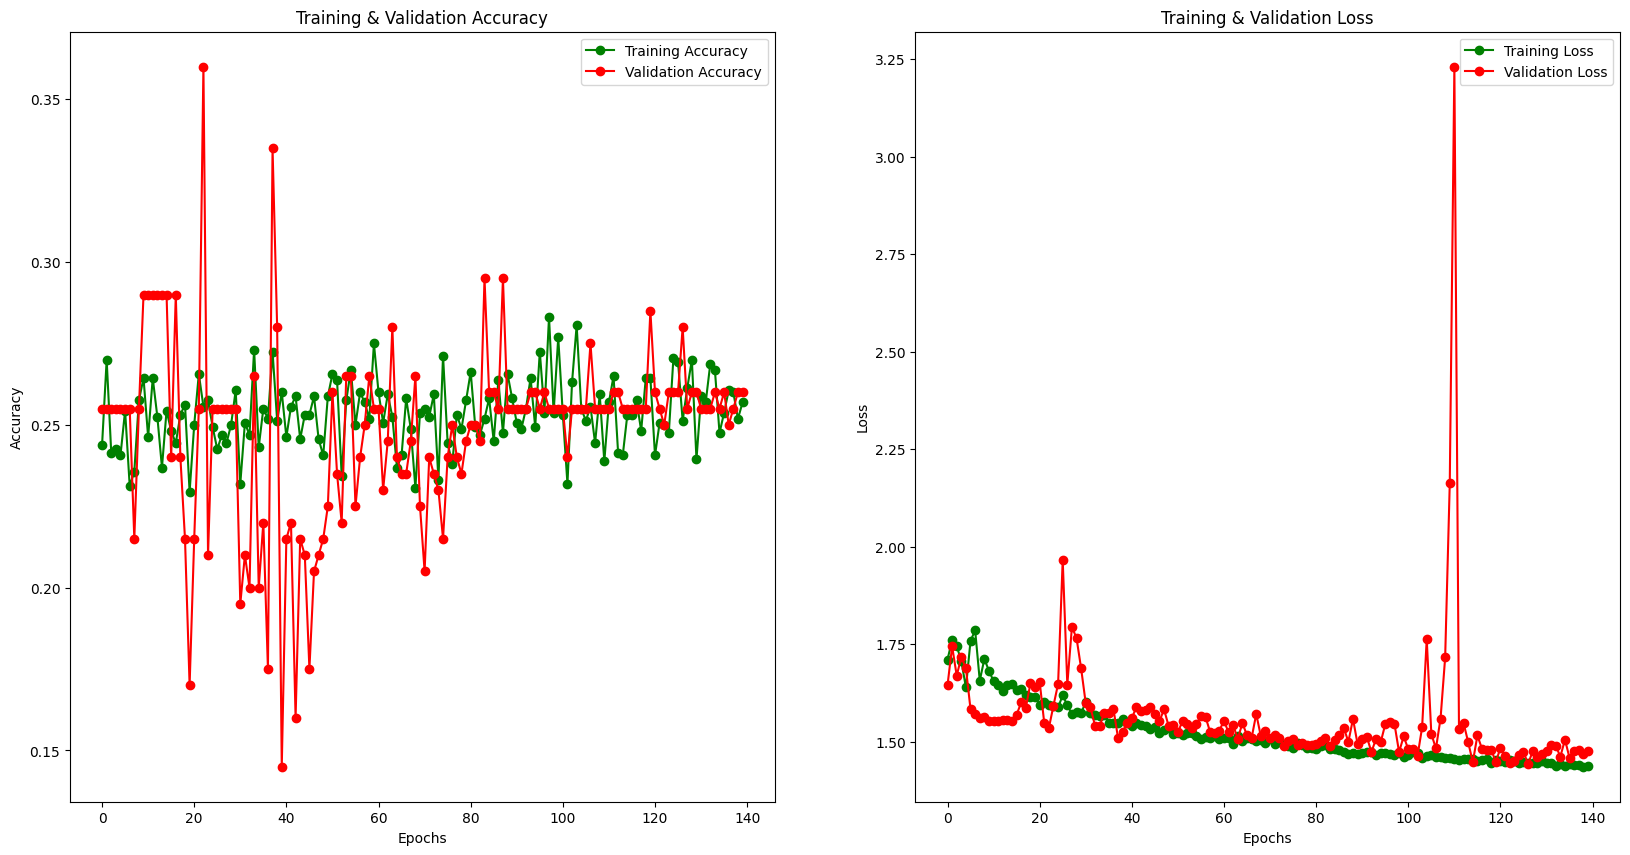

In [20]:
plot_accuracy_loss_chart(history)

In [21]:
results = model.evaluate(test_images, test_labels)

print("Loss of the model is: ", results[0])
print("Accuracy of the model is: ", results[1] * 100, "%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.2418 - loss: 57.7430
Loss of the model is:  55.986854553222656
Accuracy of the model is:  24.500000476837158 %


In [22]:
classes = list(class_names)

cm = confusion_matrix(test_labels, y_pred)
cm

array([[ 0,  3,  0, 53],
       [ 0, 11,  0, 38],
       [ 1,  7,  0, 42],
       [ 0,  1,  0, 44]])

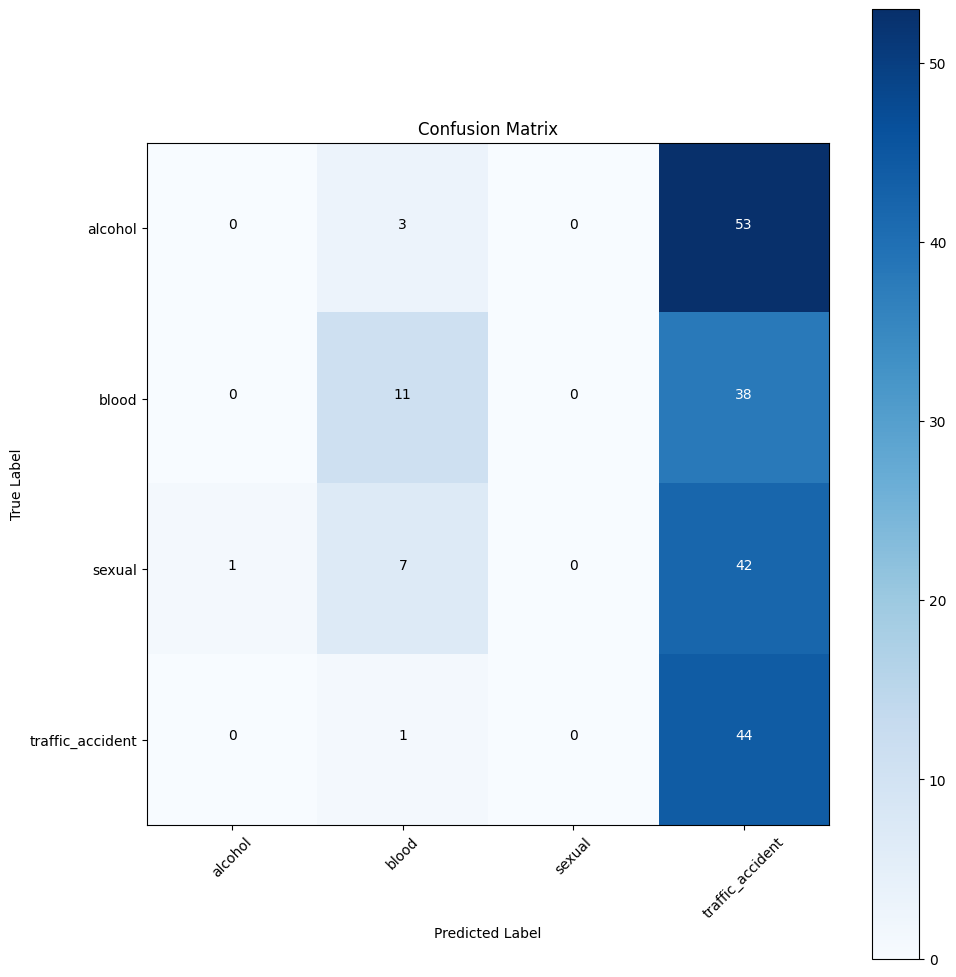

In [23]:
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [24]:
print(classification_report(test_labels, y_pred, target_names=classes))

                  precision    recall  f1-score   support

         alcohol       0.00      0.00      0.00        56
           blood       0.50      0.22      0.31        49
          sexual       0.00      0.00      0.00        50
traffic_accident       0.25      0.98      0.40        45

        accuracy                           0.28       200
       macro avg       0.19      0.30      0.18       200
    weighted avg       0.18      0.28      0.17       200

